# CellorNuc Starter Quiz

Xiuyuan Lu

## Setup and Method Overview

In [1]:
%matplotlib inline
from pathlib import Path
import sys

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns

ROOT = Path("..") if Path("../scanpyplus").is_dir() else Path(".")
sys.path.insert(0, str(ROOT.resolve()))
from scanpyplus import Scanpyplus

sc.settings.set_figure_params(dpi=110, facecolor="white", figsize=(5, 5))
sns.set_theme(style="whitegrid", context="notebook")

## Q1. Run the classifier on the mixed dataset A (cells + nuclei)

**Download the dataset A and run CellorNucEM on the mixed dataset A.**

In [2]:
sc_genes, sn_genes = Scanpyplus.LoadGeneSignatures()
mixed = sc.read_h5ad(ROOT / "data" / "mixed_mBDRC_5pCells_multiomeNuclei_full.h5ad")
print(f"sc signature ({len(sc_genes)} genes): {sc_genes}")
print(f"sn signature ({len(sn_genes)} genes): {sn_genes}")

sc signature (10 genes): ['EEF1A1', 'TPT1', 'FTH1', 'FTL', 'SERF2', 'ATP5F1E', 'GAPDH', 'UBA52', 'COX7C', 'MIF']
sn signature (10 genes): ['FTX', 'AGAP1', 'GMDS-DT', 'PARD3', 'WWOX', 'MAGI2', 'PKHD1', 'NHS', 'AC098829.1', 'DPP6']


### 1a

**Are there any cell droplets called Typical Nucleus (SN), or any nucleus droplets called Typical Cell (SC)? How well does the signature work on this independent dataset?** 

In [ ]:
print("Known modality counts:")
print(mixed.obs["suspension_type"].value_counts())
print("\nSequencing assay values:")
print(mixed.obs["assay"].value_counts())

q1 = Scanpyplus.CellorNucEM(
    mixed,
    sc_genes,
    sn_genes,
    layer="counts",
    assay_col="suspension_type",
    sc_label="cell",
    sn_label="nucleus",
    min_counts=10,
    gamma_hi=0.95,
    gamma_lo=0.05,
    init="anchored",
    copy=True,
    print_mode=False,
)

Known modality counts:
suspension_type
nucleus    53799
cell        7813
Name: count, dtype: int64

Sequencing assay values:
assay
10x multiome    53799
10x 5' v1        7813
Name: count, dtype: int64


In [5]:
q1_counts = pd.crosstab(
    q1.obs["suspension_type"],
    q1.obs["modality_classification"],
    dropna=False,
)
q1_percent_within_modality = q1_counts.div(q1_counts.sum(axis=1), axis=0).mul(100)

print("Classification counts:")
display(q1_counts)
print("Percent within known modality:")
display(q1_percent_within_modality)

Classification counts:


modality_classification,Typical Cell (SC),Nucleus-like Cell (SC),Typical Nucleus (SN),Cell-like Nucleus (SN),Neutral
suspension_type,,,,,
cell,7219,106,0,0,488
nucleus,0,0,36019,212,17568


Percent within known modality:


modality_classification,Typical Cell (SC),Nucleus-like Cell (SC),Typical Nucleus (SN),Cell-like Nucleus (SN),Neutral
suspension_type,,,,,
cell,92.397287,1.356713,0.000000,0.000000,6.246000
nucleus,0.000000,0.000000,66.951059,0.394059,32.654882


As we can see in the crosstab above, the answer is "NO". The zeros tell us the answer. 

In [6]:
n = q1_counts.sum(axis=1)
cross = pd.Series(
    {
        "cell": q1_counts.loc["cell", "Nucleus-like Cell (SC)"],
        "nucleus": q1_counts.loc["nucleus", "Cell-like Nucleus (SN)"],
    }
)
agree = pd.Series(
    {
        "cell": q1_counts.loc["cell", "Typical Cell (SC)"],
        "nucleus": q1_counts.loc["nucleus", "Typical Nucleus (SN)"],
    }
)
confident = n - q1_counts["Neutral"]

q1_how_well = pd.DataFrame(
    {
        "cross_modality": cross,
        "cross_modality_%": 100 * cross / n,
        "coverage_%": 100 * confident / n,
        "concordance_among_confident_%": 100 * agree / confident,
    }
)
q1_how_well

,cross_modality,cross_modality_%,coverage_%,concordance_among_confident_%
cell,106,1.356713,93.754000,98.552901
nucleus,212,0.394059,67.345118,99.414866


The percentages, namely cross_modality, coverage, and concordance_among_confident were calculated directly from the crosstab. They show that when the classifier is willing to call, the signature transfers well on this independent full dataset. 

### 1b

**Look at the distribution of obs['modality_counts'] in cells vs nuclei and, together with the parameter min_counts=10, explain where these Neutral calls come from. What are the probable reasons for the Neutral calls?**

In [7]:
classification = q1.obs["modality_classification"].astype(str)
neutral = classification.eq("Neutral")
low_evidence = q1.obs["modality_counts"].lt(10)
intermediate_posterior = q1.obs["p_cell"].between(
    0.05, 0.95, inclusive="both"
)

q1.obs["neutral_source"] = np.select(
    [
        ~neutral,
        neutral & low_evidence,
        neutral & ~low_evidence & intermediate_posterior,
    ],
    ["Not Neutral", "modality_counts < 10", "intermediate posterior"],
    default="other",
)

q1_neutral_sources = pd.crosstab(
    q1.obs.loc[neutral, "suspension_type"],
    q1.obs.loc[neutral, "neutral_source"],
)
q1_m_summary = q1.obs.groupby("suspension_type", observed=True)[
    "modality_counts"
].describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

print("Neutral calls separated by source:")
display(q1_neutral_sources)
print("modality_counts summary by known modality:")
display(q1_m_summary)

Neutral calls separated by source:


neutral_source,intermediate posterior,modality_counts < 10
suspension_type,,
cell,192,296
nucleus,2061,15507


modality_counts summary by known modality:


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
suspension_type,,,,,,,,,,,,,,
cell,7813.0,202.267887,247.486375,0.0,3.0,12.0,22.0,58.0,124.0,248.0,473.0,661.4,1203.92,4323.0
nucleus,53799.0,50.974107,90.910474,0.0,0.0,2.0,3.0,8.0,24.0,61.0,112.0,164.0,490.02,1865.0


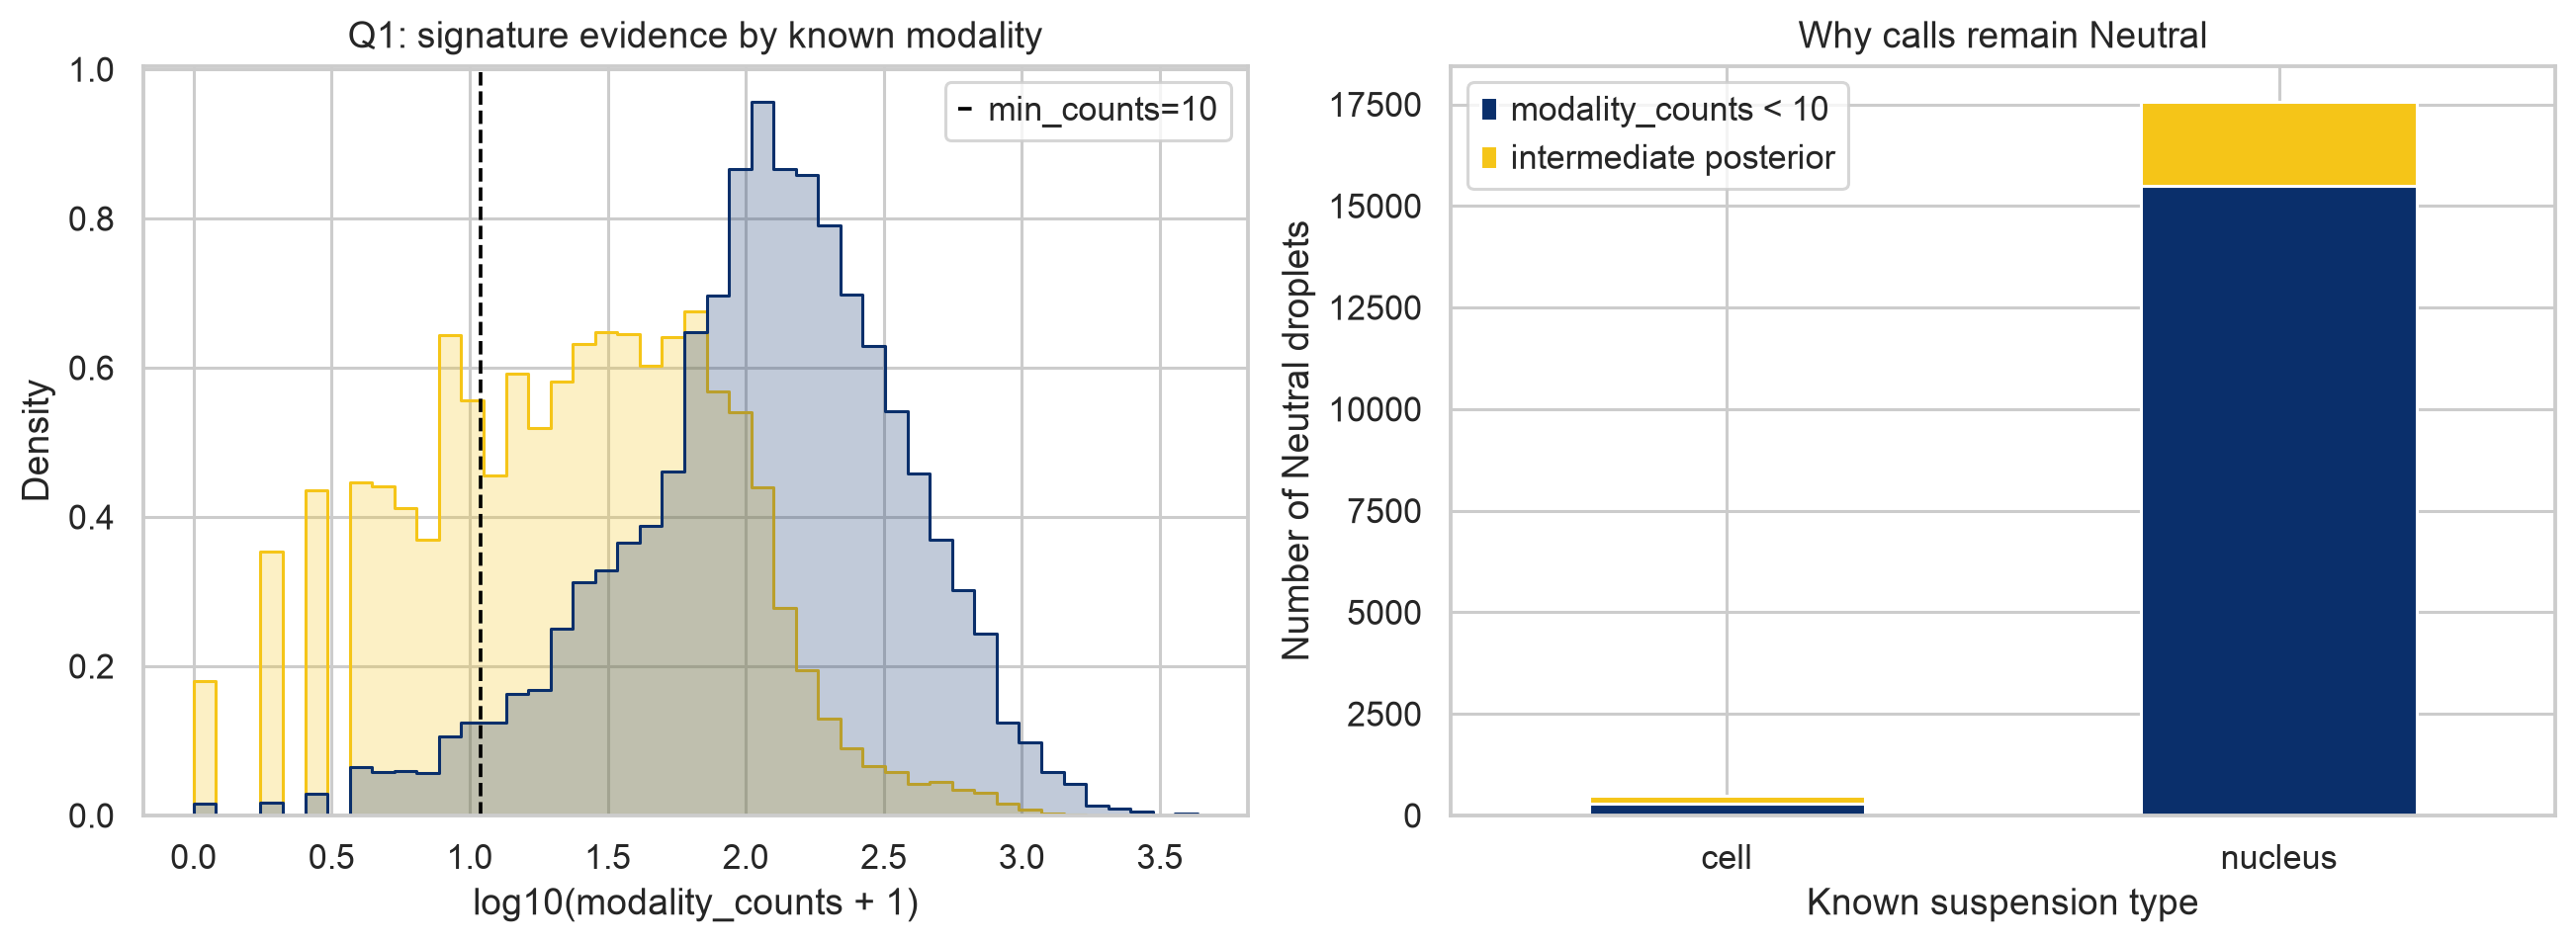

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

q1_plot = q1.obs[["suspension_type", "modality_counts"]].copy()
q1_plot["log10_modality_counts_plus_1"] = np.log10(q1_plot["modality_counts"] + 1)

palette = {"cell": "#0A2F6B", "nucleus": "#F5C518"}
sns.histplot(
    data=q1_plot,
    x="log10_modality_counts_plus_1",
    hue="suspension_type",
    palette=palette,
    bins=45,
    element="step",
    stat="density",
    common_norm=False,
    ax=axes[0],
)

axes[0].axvline(
    np.log10(10 + 1), # keeps m=0 on the axis; log10(11)=1.04
    color="black",
    linestyle="--",
    linewidth=1.2,
    label="min_counts=10",
)
axes[0].set_title("Q1: signature evidence by known modality")
axes[0].set_xlabel("log10(modality_counts + 1)")
axes[0].legend(title=None)

source_order = ["modality_counts < 10", "intermediate posterior"]
neutral_plot = q1_neutral_sources.reindex(columns=source_order, fill_value=0)
neutral_plot.plot(
    kind="bar",
    stacked=True,
    color=["#0A2F6B", "#F5C518"],
    ax=axes[1],
)
axes[1].set_title("Why calls remain Neutral")
axes[1].set_xlabel("Known suspension type")
axes[1].set_ylabel("Number of Neutral droplets")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title=None)

plt.tight_layout()
plt.show()

modality_counts is the sum of counts over the available sc and sn signature genes, not total transcript counts. Its distributuion is substantially lower for nuclei than cells, as we can directly see from the distribution (the left plot). Everything left of the dotted line has m<10 and is Neutral by rule, no matter how cell-like or nucleus-like the fraction looks. The remaining Neutrals sit right of the line. They have enough modality counts, but $0.05 \leq p_{\text{cell}} \leq 0.95$. Those are also shown as the "intemediate posterior" bar on the right. 

## Q2. Run on the single-modality dataset B (sc only)

**Many real projects have only sc (or only sn) data. There, the classifier is used to find droplets of the "other kind" that slipped in -- for example, droplets in an sc library whose cytoplasm lysed, leaving only the nucleus.** 

In [3]:
single = sc.read_h5ad(ROOT / "data" / "single_KidneyRaji_sc_full.h5ad")

### 2a

**Load dataset B and run CellorNucEM. What fraction of droplets are Nucleus-like Cell (SC)?**

In [10]:
q2_input = single.copy()
q2_input.obs["modality"] = "sc"

q2 = Scanpyplus.CellorNucEM(
    q2_input,
    sc_genes,
    sn_genes,
    assay_col="modality",
    layer="counts",
    min_counts=10,
    copy=True,
    gamma_hi=0.95,
    gamma_lo=0.05,
    init="anchored",
    max_p_nuc=0.2,
    min_p_cell=0.8,
    print_mode=False,
)

In [12]:
q2_counts = q2.obs["modality_classification"].value_counts()
q2_frac = q2_counts / q2.n_obs
print("Classification summary:")
display(pd.concat([q2_counts.rename("count"), q2_frac.rename("fraction")], axis=1))

Classification summary:


,count,fraction
modality_classification,,
Typical Cell (SC),116406,0.972262
Nucleus-like Cell (SC),3321,0.027738


The result is clearly shown in the table above. $2.77 \%$ droplets are Nucleus-like Cell.. 

### 2b

**Plot a histogram of `sc_frac`. Is it unimodal or bimodal?**

undefined sc_frac (modality_counts = 0): 589


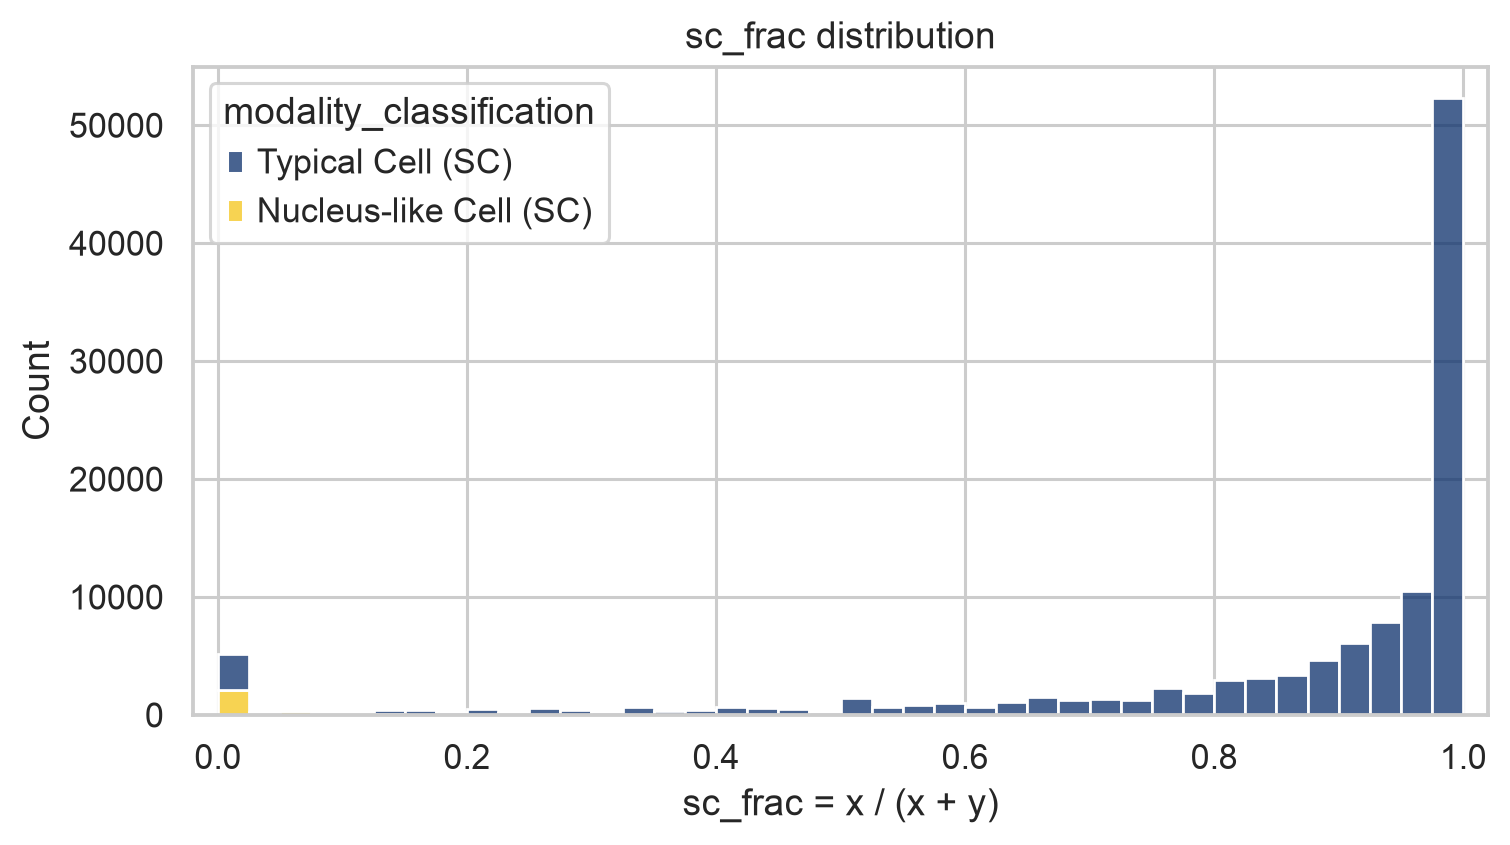

In [17]:
print("undefined sc_frac (modality_counts = 0):", int(q2.obs["sc_frac"].isna().sum()))

fig, ax = plt.subplots(figsize=(7, 4))
palette = {"Nucleus-like Cell (SC)": "#F5C518", "Typical Cell (SC)": "#0A2F6B"}
q2_plot = q2.obs[["sc_frac", "modality_classification"]].copy()
sns.histplot(
    data=q2_plot,
    x="sc_frac",
    hue="modality_classification",
    palette=palette,
    bins=np.linspace(0, 1, 41),
    multiple="stack",
    ax=ax,
)
ax.set_title("sc_frac distribution")
ax.set_xlim(-0.02, 1.02)
ax.set_xlabel("sc_frac = x / (x + y)")
plt.tight_layout()
plt.show()

How to tell whether it is unimodal or bimodal? Read it from the histogram!

A dominant pile near 1 plus a distinct pile near 0 means it is bimodal, even if the low pile is much smaller. Maybe we should call it the "imbalanced bimodality"?

## Q3: Anchor vs. Split

**CellorNucEM has an "anchor" related mechanism.**

### 3a

**On dataset B, run (i) the default parameters; `init="anchored"`, (ii) `init="split"`. Compare the two component means $p$ between the two fits. Are the differences large? If yes, what could be the reasons?**

In [18]:
def component_means(adata):
    fit = adata.uns["modality_em"]["global"]
    a_cell, b_cell = fit["ab_cell"]
    a_nuc, b_nuc = fit["ab_nuc"]
    return pd.Series(
        {
            "p_cell": a_cell / (a_cell + b_cell),
            "p_nuc": a_nuc / (a_nuc + b_nuc),
        }
    )

q3a = {}
for init in ("anchored", "split"):
    fitted = Scanpyplus.CellorNucEM(
        single, sc_genes, sn_genes, layer="counts", init=init, copy=True, print_mode=False
    )
    q3a[init] = component_means(fitted)

q3a = pd.DataFrame(q3a).T
q3a.loc["abs_diff"] = (q3a.loc["anchored"] - q3a.loc["split"]).abs()
q3a

,p_cell,p_nuc
anchored,0.920773,0.388908
split,0.923955,0.640799
abs_diff,0.003182,0.251891


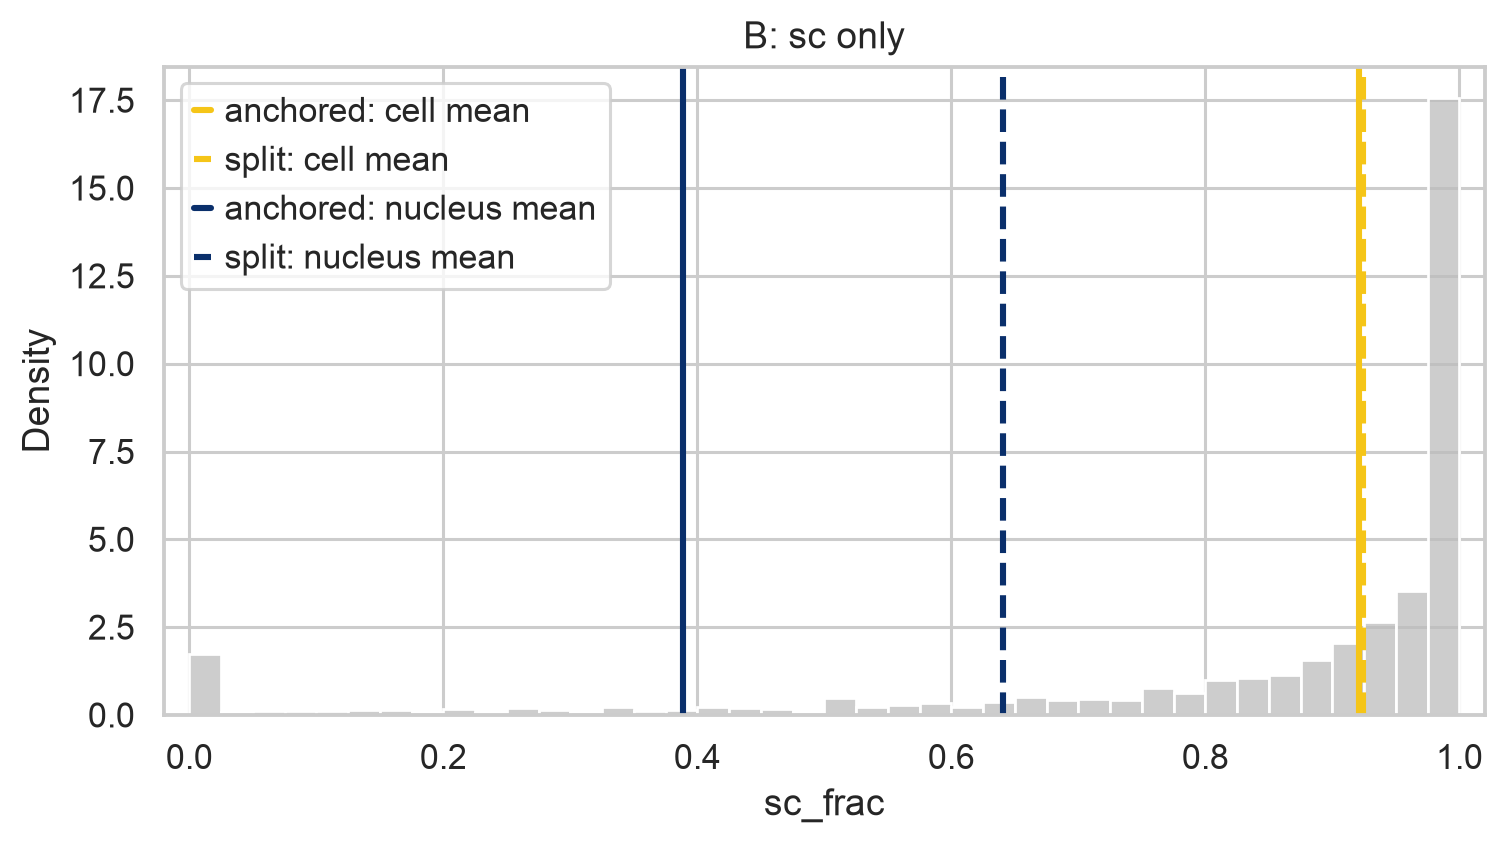

In [19]:
def plot_component_means(sc_frac, means, title):
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.histplot(
        sc_frac.dropna(),
        bins=np.linspace(0, 1, 41),
        stat="density",
        color="#bdbdbd",
        ax=ax,
    )
    ax.axvline(means.loc["anchored", "p_cell"], color="#F5C518", ls="-", lw=2, label="anchored: cell mean")
    ax.axvline(means.loc["split", "p_cell"], color="#F5C518", ls="--", lw=2, label="split: cell mean")
    ax.axvline(means.loc["anchored", "p_nuc"], color="#0A2F6B", ls="-", lw=2, label="anchored: nucleus mean")
    ax.axvline(means.loc["split", "p_nuc"], color="#0A2F6B", ls="--", lw=2, label="split: nucleus mean")
    ax.set_xlim(-0.02, 1.02)
    ax.set_xlabel("sc_frac")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


# Same sc_frac for both inits; q2 already computed it on dataset B.
plot_component_means(q2.obs["sc_frac"], q3a, "B: sc only")


### 3b

**Switch to dataset A: take only droplets with `suspension_type=="cell"` and compare (i) and (ii) in the same way; then do the same with nucleus only.**

,p_cell,p_nuc
anchored,0.972187,0.621174
split,0.973697,0.847522
abs_diff,0.001510,0.226348


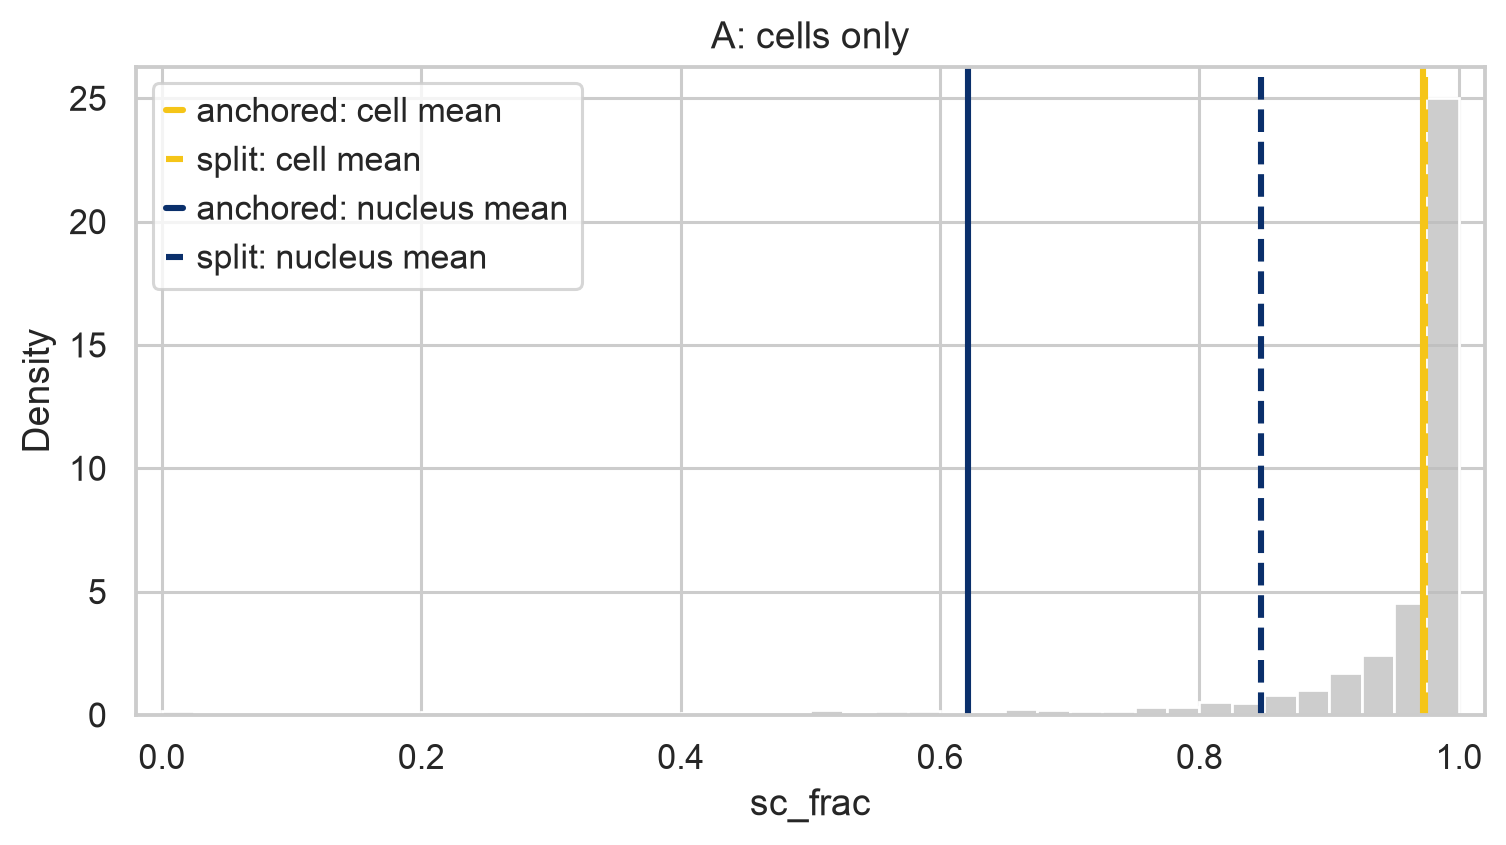

In [20]:
q3b_cells = {}
q3b_cells_sc_frac = None
for init in ("anchored", "split"):
    fitted = Scanpyplus.CellorNucEM(
        mixed[mixed.obs["suspension_type"] == "cell"],
        sc_genes,
        sn_genes,
        layer="counts",
        init=init,
        copy=True,
        print_mode=False,
    )
    q3b_cells[init] = component_means(fitted)
    if q3b_cells_sc_frac is None:
        q3b_cells_sc_frac = fitted.obs["sc_frac"].copy()

q3b_cells = pd.DataFrame(q3b_cells).T
q3b_cells.loc["abs_diff"] = (q3b_cells.loc["anchored"] - q3b_cells.loc["split"]).abs()
display(q3b_cells)
plot_component_means(q3b_cells_sc_frac, q3b_cells, "A: cells only")


,p_cell,p_nuc
anchored,0.348013,0.079533
split,0.172021,0.068768
abs_diff,0.175992,0.010765


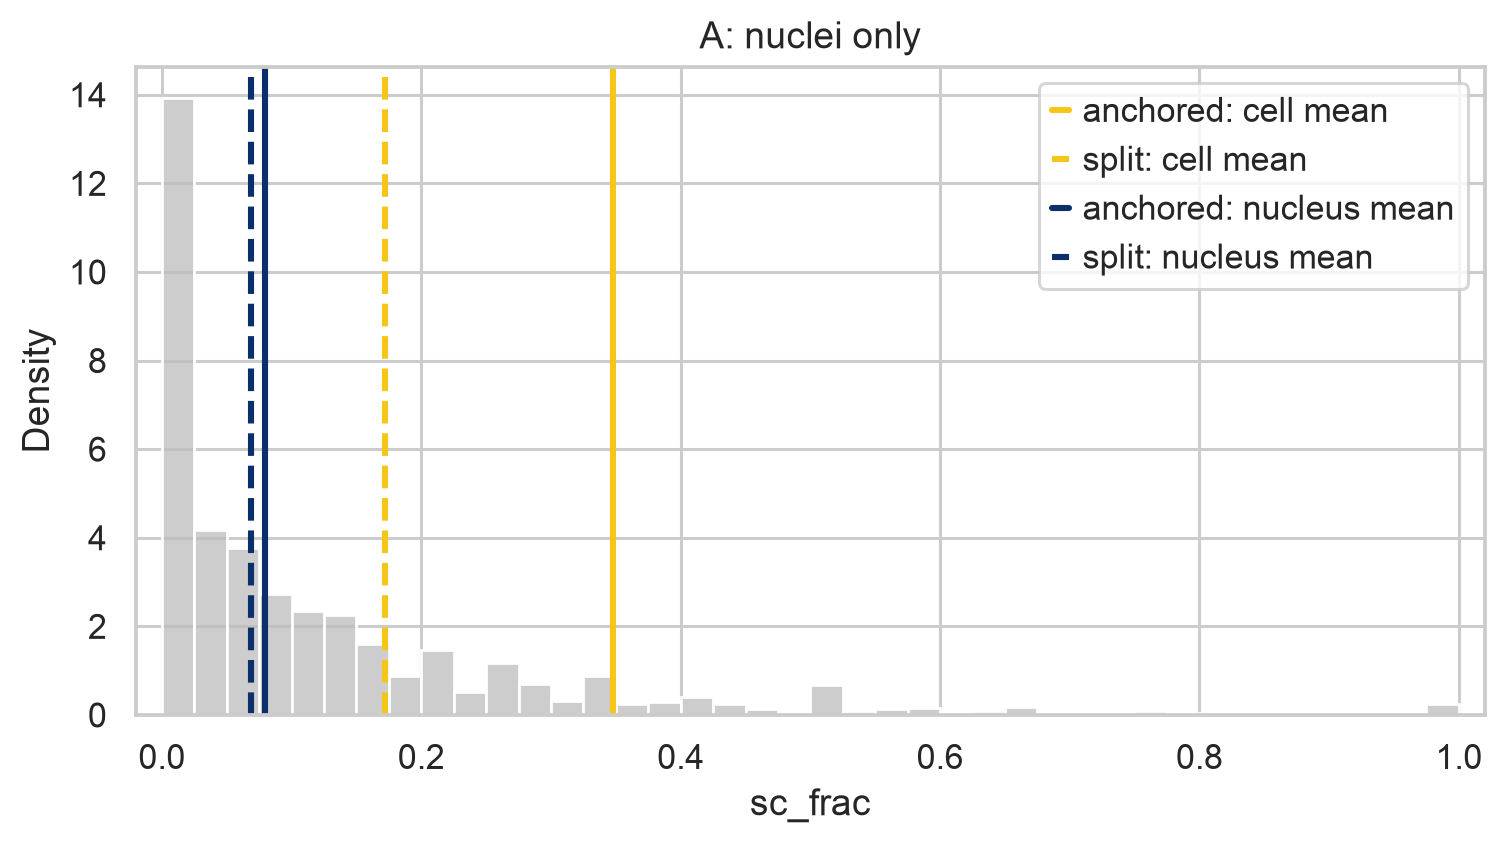

In [21]:
q3b_nuclei = {}
q3b_nuclei_sc_frac = None
for init in ("anchored", "split"):
    fitted = Scanpyplus.CellorNucEM(
        mixed[mixed.obs["suspension_type"] == "nucleus"],
        sc_genes,
        sn_genes,
        layer="counts",
        init=init,
        copy=True,
        print_mode=False,
    )
    q3b_nuclei[init] = component_means(fitted)
    if q3b_nuclei_sc_frac is None:
        q3b_nuclei_sc_frac = fitted.obs["sc_frac"].copy()

q3b_nuclei = pd.DataFrame(q3b_nuclei).T
q3b_nuclei.loc["abs_diff"] = (q3b_nuclei.loc["anchored"] - q3b_nuclei.loc["split"]).abs()
display(q3b_nuclei)
plot_component_means(q3b_nuclei_sc_frac, q3b_nuclei, "A: nuclei only")


## Bonus

## Conclusion